# ML-06 — Signal Audit: Do the Flags Hold?

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/mariamemad975/FlyRank_ML/blob/main/work/notebooks/w04_signal_audit.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Distributions

*Look before deciding: distributions of your key fields. Note the heavy tails.*

In [7]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
import duckdb
from google.colab import userdata
from huggingface_hub import hf_hub_download

token = userdata.get("HF_TOKEN")
file = hf_hub_download(
    repo_id="FlyRank/internship-warehouse",
    filename="fact_content_daily_performance/month=2026-03/data_0.parquet",
    repo_type="dataset",
    token=token)

connect = duckdb.connect()
feature_df = connect.execute(f"""
    SELECT
        content_hash_id,
        SUM(gsc_impressions) AS total_gsc_impressions,
        SUM(gsc_clicks) AS total_gsc_clicks,
        CASE
            WHEN SUM(gsc_impressions) > 0
            THEN SUM(gsc_clicks) * 1.0 / SUM(gsc_impressions)
            ELSE 0
        END AS ctr,
        SUM(ga4_pageviews) AS total_ga4_pageviews,
        SUM(ga4_sessions) AS total_ga4_sessions,
        MAX(CASE WHEN client_has_gsc THEN 1 ELSE 0 END) AS has_gsc_bool,
        MAX(CASE WHEN client_has_ga4 THEN 1 ELSE 0 END) AS has_ga4_bool,
        COUNT(*) AS days_observed
    FROM '{file}'
    WHERE gsc_data_available = TRUE
    GROUP BY content_hash_id""").df()

feature_df = feature_df.fillna(0)
print("Feature vector shape:", feature_df.shape)
display(feature_df.head())

Feature vector shape: (176738, 9)


,content_hash_id,total_gsc_impressions,total_gsc_clicks,ctr,total_ga4_pageviews,total_ga4_sessions,has_gsc_bool,has_ga4_bool,days_observed
0,content_b7e512995f79d5a6,1140.0,2.0,0.001754,0.0,0.0,1,1,31
1,content_05597932fe4da067,57.0,0.0,0.000000,0.0,0.0,1,1,26
2,content_905aa32a0230694e,149.0,0.0,0.000000,4.0,4.0,1,1,30
3,content_05434271b257bb68,1421.0,6.0,0.004222,12.0,9.0,1,1,31
4,content_d056587ff7faca0c,2770.0,16.0,0.005776,3.0,3.0,1,1,31


The volume-based features (impressions, clicks, pageviews, and sessions) are strongly right-skewed. A small number of pages receive most of the traffic, so the median is much lower than the mean. CTR is limited to a range of 0–1 and has a more balanced distribution, but many pages have a CTR of 0 because they received no clicks. Days observed is mostly around 31 days, indicating full-month coverage, with fewer pages having data for only part of the month.

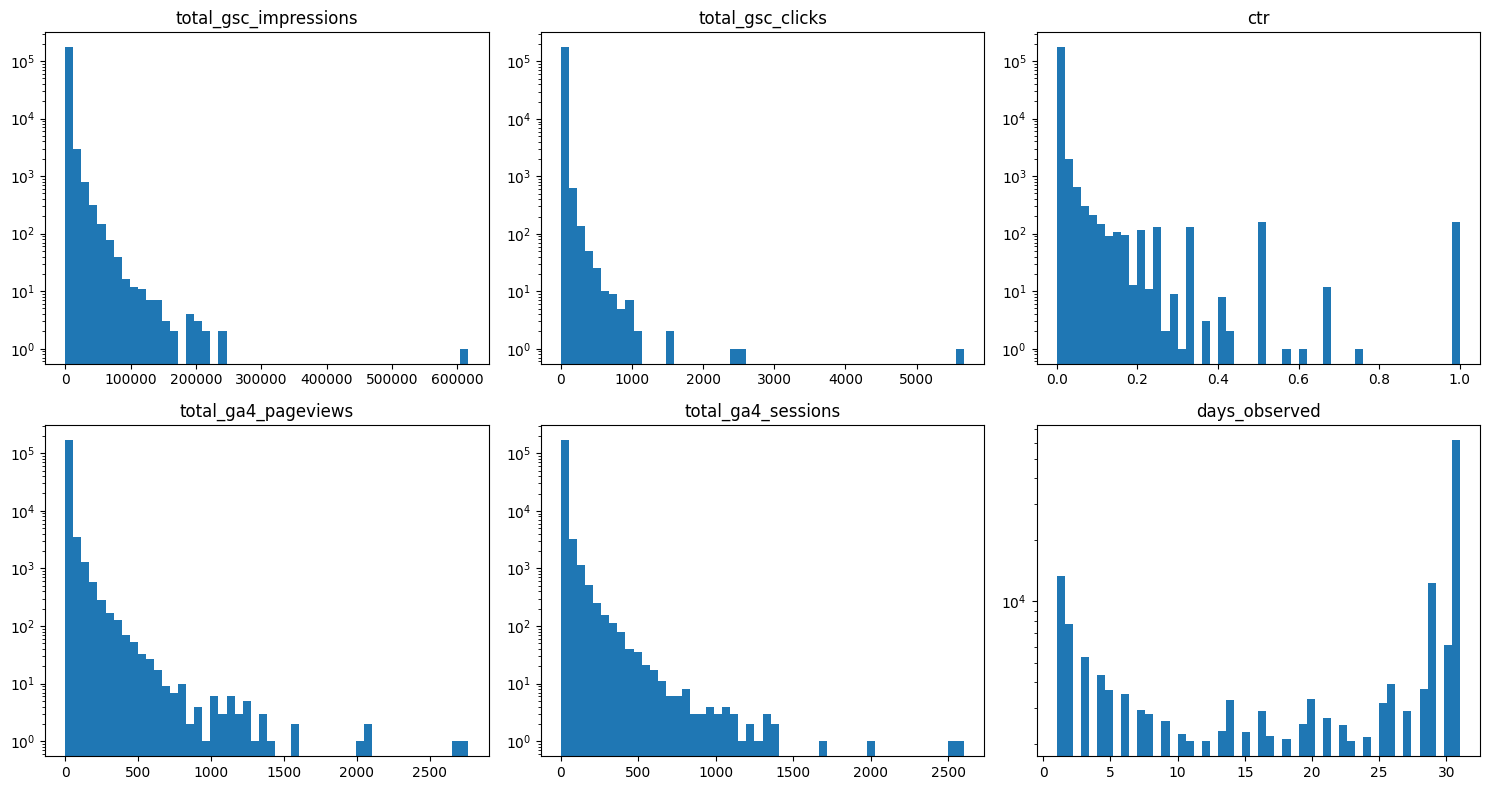

,total_gsc_impressions,total_gsc_clicks,ctr,total_ga4_pageviews,total_ga4_sessions,days_observed
count,176738.000000,176738.000000,176738.000000,176738.000000,176738.000000,176738.000000
mean,1587.986675,4.650002,0.004594,8.022134,7.008991,20.431718
std,5431.337724,26.722649,0.037760,38.166608,34.204626,11.480153
min,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000
50%,173.000000,0.000000,0.000000,0.000000,0.000000,26.000000
90%,3930.000000,10.000000,0.006154,15.000000,12.000000,31.000000
95%,7238.150000,22.000000,0.010870,39.000000,33.000000,31.000000
99%,21799.780000,73.000000,0.058824,147.000000,129.630000,31.000000
max,617124.000000,5668.000000,1.000000,2767.000000,2603.000000,31.000000


In [10]:
import matplotlib.pyplot as plt
fields = [
    'total_gsc_impressions',
    'total_gsc_clicks',
    'ctr',
    'total_ga4_pageviews',
    'total_ga4_sessions',
    'days_observed']
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, field in zip(axes.flat, fields):
    ax.hist(feature_df[field], bins=50)
    ax.set_title(field)
    ax.set_yscale('log')
plt.tight_layout()
plt.show()

display(feature_df[fields].describe(percentiles=[0.5, 0.9, 0.95, 0.99]))

## 2. Signal test #1 / #2 / #3 (verdict each)

*Three safe signals, each with a mini-test and a verdict: CONFIRMED / OPPOSITE / MIXED / FALSE.*

In [12]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.

median_sessions = feature_df['total_ga4_sessions'].median()
high_sessions = feature_df[
    feature_df['total_ga4_sessions'] > median_sessions]['ctr']
low_sessions = feature_df[
    feature_df['total_ga4_sessions'] <= median_sessions]['ctr']

print("Signal 1: Do pages with more GA4 sessions have higher CTR?")
print("High-session group mean CTR:", round(high_sessions.mean(), 4))
print("Low-session group mean CTR: ", round(low_sessions.mean(), 4))

Signal 1: Do pages with more GA4 sessions have higher CTR?
High-session group mean CTR: 0.0083
Low-session group mean CTR:  0.0025


In [13]:
median_days = feature_df['days_observed'].median()
full_month = feature_df[
    feature_df['days_observed'] >= median_days]['total_gsc_impressions']
partial_month = feature_df[
    feature_df['days_observed'] < median_days]['total_gsc_impressions']

print("Signal 2: Do pages with more observed days have higher impressions?")
print("Full-month group mean impressions:", round(full_month.mean(), 2))
print("Partial-month group mean impressions:", round(partial_month.mean(), 2))

Signal 2: Do pages with more observed days have higher impressions?
Full-month group mean impressions: 2935.3
Partial-month group mean impressions: 168.93


In [14]:
ga4_yes = feature_df[
    feature_df['has_ga4_bool'] == 1]['total_gsc_clicks']
ga4_no = feature_df[
    feature_df['has_ga4_bool'] == 0]['total_gsc_clicks']

print("Signal 3: Do pages with GA4 data have higher GSC clicks?")
print("GA4 available mean clicks:", round(ga4_yes.mean(), 2))
print("GA4 not available mean clicks:", round(ga4_no.mean(), 2))

Signal 3: Do pages with GA4 data have higher GSC clicks?
GA4 available mean clicks: 5.07
GA4 not available mean clicks: 3.54


## 3. The flag-linked test

*Pick a signal one of FlyRank's real flags relies on. Does the data support the rule's assumption?*

Flag tested: ML-04 decay flag — pos_last30 > 81.7 (worse than the median position).

Assumption: A worse position means lower engagement.

Finding: Flagged pages had lower CTR (0.0026 vs. 0.0066) and GSC clicks (2.43 vs. 6.87), supporting the assumption. However, they had higher GA4 sessions (9.64 vs. 4.38).

Verdict: MIXED. The flag works for search engagement, but not for overall engagement because GA4 sessions show the opposite result.

In [18]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
position_lookup = con.execute(f"""
    SELECT
        content_hash_id,
        AVG(gsc_avg_position) AS avg_position
    FROM '{local_parquet_path}'
    WHERE gsc_data_available = TRUE
    GROUP BY content_hash_id""").df()

median_position = position_lookup['avg_position'].median()
position_lookup['flagged_decay'] = (
    position_lookup['avg_position'] > median_position)

flag_test = feature_df.merge(
    position_lookup[['content_hash_id', 'flagged_decay']],
    on='content_hash_id')

flagged = flag_test[flag_test['flagged_decay']]
not_flagged = flag_test[~flag_test['flagged_decay']]

print(f"Flagged pages: {len(flagged)} ({len(flagged) / len(flag_test) * 100:.1f}%)")
print("\nCTR:")
print("Flagged:", round(flagged['ctr'].mean(), 4))
print("Not flagged:", round(not_flagged['ctr'].mean(), 4))
print("\nGSC clicks:")
print("Flagged:", round(flagged['total_gsc_clicks'].mean(), 2))
print("Not flagged:", round(not_flagged['total_gsc_clicks'].mean(), 2))
print("\nGA4 sessions:")
print("Flagged:", round(flagged['total_ga4_sessions'].mean(), 2))
print("Not flagged:", round(not_flagged['total_ga4_sessions'].mean(), 2))

Flagged pages: 88369 (50.0%)

CTR:
Flagged: 0.0026
Not flagged: 0.0066

GSC clicks:
Flagged: 2.43
Not flagged: 6.87

GA4 sessions:
Flagged: 9.64
Not flagged: 4.38


## 4. What this means in practice

*Two or three sentences: what a content team should take from this.*

The position-decay flag is a useful search-engagement signal because flagged pages have lower CTR and clicks. However, GA4 sessions are higher, so the content is not necessarily losing overall engagement.

Recommendation: Treat the flag as “search visibility is declining”, not “the content is failing.” Check on-site engagement separately before deciding to rewrite or deprioritize a page.

In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.